In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task 6: House Price Prediction

**Objective:** Predict house prices using property features such as size, bedrooms, and location.
**Dataset:** California Housing Dataset (Scikit-Learn built-in, similar to Kaggle datasets).

**Goals for this Notebook:**
1. Perform preprocessing on features.
2. Train a Gradient Boosting regression model.
3. Evaluate with Mean Absolute Error (MAE) and RMSE.
4. Visualize predicted prices compared to actual prices.

Loading Housing Data...
Training Gradient Boosting Regressor...

 Mean Absolute Error (MAE): 0.37
 Root Mean Squared Error (RMSE): 0.54


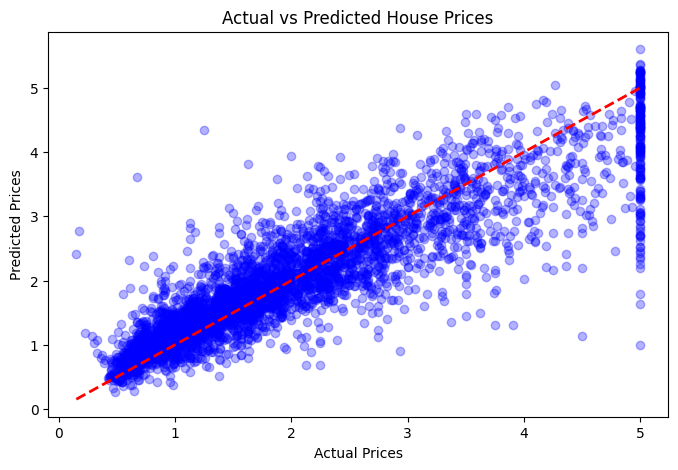

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# 1. Dataset Loading & Preprocessing
# ==========================================
print("Loading Housing Data...")
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Features (X) and Target (y - Price in 100k$)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Model Training (Gradient Boosting)
# ==========================================
print("Training Gradient Boosting Regressor...")
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ==========================================
# 3. Model Evaluation (MAE & RMSE)
# ==========================================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n Mean Absolute Error (MAE): {mae:.2f}")
print(f" Root Mean Squared Error (RMSE): {rmse:.2f}")

# ==========================================
# 4. Data Visualization (Actual vs Predicted)
# ==========================================
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()